# Normalizing Flows

I Normalizing Flows sono modelli neurali che imparano trasformazioni invertibili per mappare i dati su una distribuzione semplice (gaussiana standard). Rispetto a KDE e GMM sono più espressivi e possono modellare distribuzioni complesse senza assumere forme parametriche fisse.

L'architettura usata è AutoregressiveRationalQuadraticSpline con 8 strati e LULinearPermute come permutazione tra gli strati. Il training usa Adam con StepLR scheduler e gradient clipping per stabilizzare la convergenza. La soglia e la metrica sono le stesse degli altri modelli.

Training NF su valve1/1.csv...


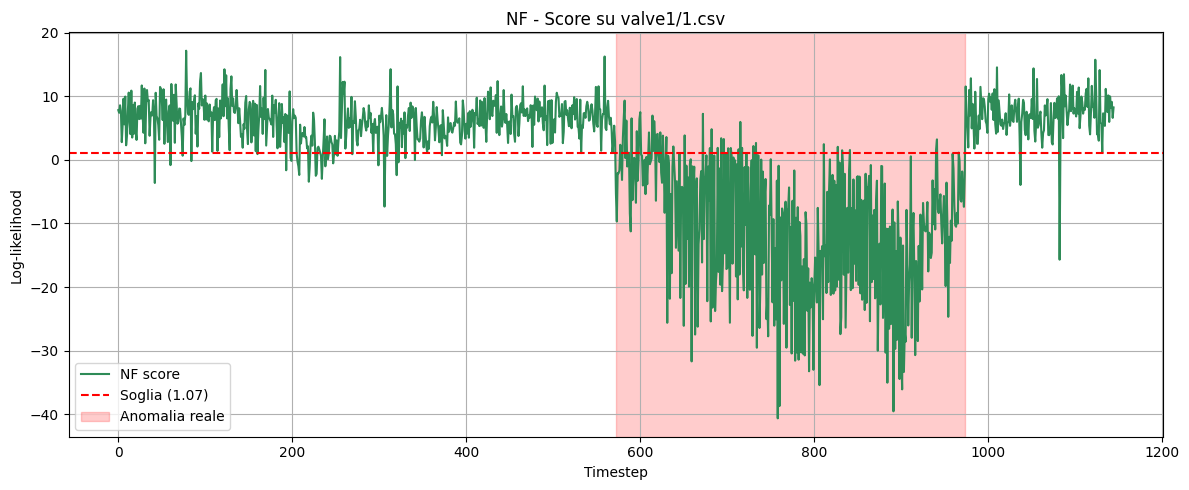

Anomalia inizia al timestep: 572
Prima detezione: 572
Ritardo: 0 timestep


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os
import torch
import normflows as nf
from sklearn.preprocessing import StandardScaler

with open("preprocessing.pkl", "rb") as f:
    prep = pickle.load(f)

features = prep["features"]
all_files = prep["all_files"]

def train_and_evaluate_nf(fpath, features, n_epochs=500):
    df = pd.read_csv(fpath, sep=";")
    df_normal = df[df["anomaly"] == 0]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_normal[features].values)
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    
    dim = X_train.shape[1]
    flows = []
    for _ in range(8):
        flows.append(nf.flows.AutoregressiveRationalQuadraticSpline(dim, 2, 64))
        flows.append(nf.flows.LULinearPermute(dim))
    
    q0 = nf.distributions.DiagGaussian(dim, trainable=False)
    model = nf.NormalizingFlow(q0=q0, flows=flows)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
    
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        loss = model.forward_kld(X_tensor)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        loss.backward()
        optimizer.step()
        scheduler.step()
    
    model.eval()
    X_all = scaler.transform(df[features].values)
    X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
    
    with torch.no_grad():
        scores_train_nf = model.log_prob(X_tensor).numpy()
        scores_all = model.log_prob(X_all_tensor).numpy()
    
    threshold = np.percentile(scores_train_nf, 5)
    
    first_real = df[df["anomaly"] == 1].index[0]
    detections = np.where(scores_all < threshold)[0]
    detections_after = detections[detections >= first_real]
    
    if len(detections_after) > 0:
        first_detected = detections_after[0]
        delay = first_detected - first_real
    else:
        first_detected = None
        delay = None
    
    return {
        "first_real": first_real,
        "first_detected": first_detected,
        "delay": delay,
        "scores": scores_all,
        "threshold": threshold,
        "df": df
    }

# Test su valve1/1.csv prima
print("Training NF su valve1/1.csv...")
result = train_and_evaluate_nf(all_files[1], features)

plt.figure(figsize=(12, 5))
plt.plot(result["scores"], color="seagreen", label="NF score")
plt.axhline(y=result["threshold"], color="red", linestyle="--",
            label=f"Soglia ({result['threshold']:.2f})")
anomaly_idx = result["df"][result["df"]["anomaly"] == 1].index
plt.axvspan(anomaly_idx[0], anomaly_idx[-1], alpha=0.2, color="red", label="Anomalia reale")
plt.xlabel("Timestep")
plt.ylabel("Log-likelihood")
plt.title("NF - Score su valve1/1.csv")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Anomalia inizia al timestep: {result['first_real']}")
print(f"Prima detezione: {result['first_detected']}")
print(f"Ritardo: {result['delay']} timestep")

## Risultati su tutti i file

Il training viene eseguito per-file (500 epoche per file), il che richiede qualche minuto in totale.

In [2]:
results_nf = []
for i, fpath in enumerate(all_files):
    print(f"Training {i+1}/{len(all_files)}: {fpath.split('/')[-2]}/{fpath.split('/')[-1]}")
    res = train_and_evaluate_nf(fpath, features)
    folder = fpath.split("/")[-2]
    fname = fpath.split("/")[-1]
    results_nf.append({
        "file": f"{folder}/{fname}",
        "folder": folder,
        "first_real": res["first_real"],
        "first_detected": res["first_detected"],
        "delay": res["delay"]
    })

df_results_nf = pd.DataFrame(results_nf)
print(df_results_nf[["file", "delay"]])
print(f"\nRitardo medio: {df_results_nf['delay'].mean():.1f} timestep")
print(f"Non rilevati: {df_results_nf['delay'].isna().sum()}")

Training 1/34: valve1/0.csv
Training 2/34: valve1/1.csv
Training 3/34: valve1/10.csv
Training 4/34: valve1/11.csv
Training 5/34: valve1/12.csv
Training 6/34: valve1/13.csv
Training 7/34: valve1/14.csv
Training 8/34: valve1/15.csv
Training 9/34: valve1/2.csv
Training 10/34: valve1/3.csv
Training 11/34: valve1/4.csv
Training 12/34: valve1/5.csv
Training 13/34: valve1/6.csv
Training 14/34: valve1/7.csv
Training 15/34: valve1/8.csv
Training 16/34: valve1/9.csv
Training 17/34: valve2/0.csv
Training 18/34: valve2/1.csv
Training 19/34: valve2/2.csv
Training 20/34: valve2/3.csv
Training 21/34: other/1.csv
Training 22/34: other/10.csv
Training 23/34: other/11.csv
Training 24/34: other/12.csv
Training 25/34: other/13.csv
Training 26/34: other/14.csv
Training 27/34: other/2.csv
Training 28/34: other/3.csv
Training 29/34: other/4.csv
Training 30/34: other/5.csv
Training 31/34: other/6.csv
Training 32/34: other/7.csv
Training 33/34: other/8.csv
Training 34/34: other/9.csv
             file  delay
0

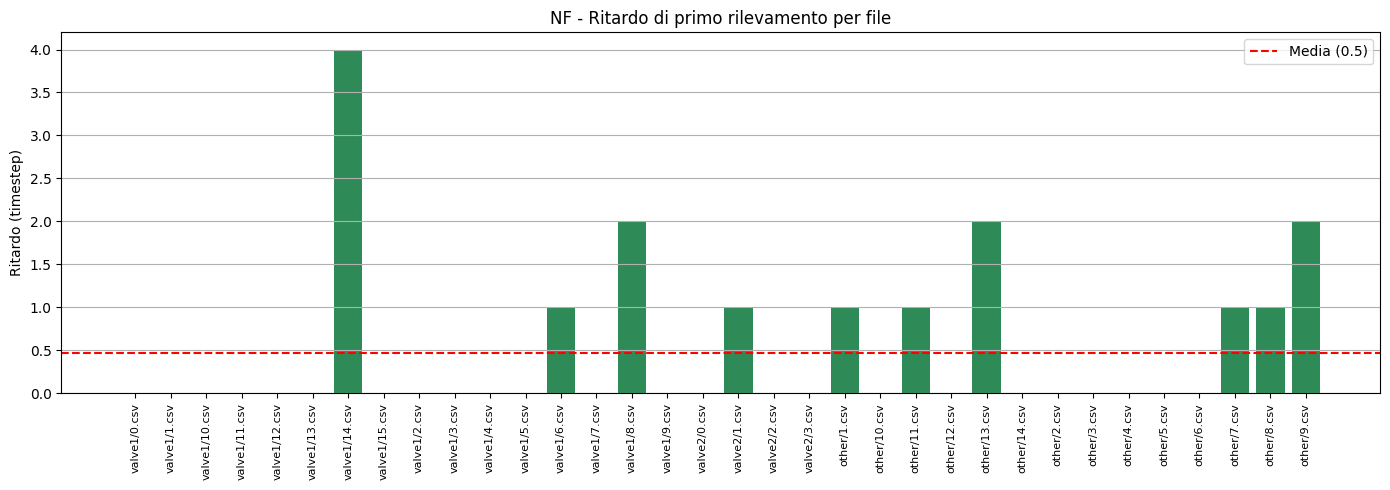

In [3]:
plt.figure(figsize=(14, 5))
plt.bar(df_results_nf["file"], df_results_nf["delay"], color="seagreen")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Ritardo (timestep)")
plt.title("NF - Ritardo di primo rilevamento per file")
plt.axhline(y=df_results_nf["delay"].mean(), color="red", linestyle="--",
            label=f"Media ({df_results_nf['delay'].mean():.1f})")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()